# 03 — Comparación de algoritmos (Benchmark 3D-BPP)

> **Catálogo homogéneo `showcase_master_catalog.json`** — mismos SKUs P1–P5 en 3D-BPP, Container Loading y Single Container. Cada tipo usa una **instancia showcase** compleja donde el benchmark **diferencia** los algoritmos del grupo.

**Instancia:** `showcase_3d_bpp_instance.json`

## Flujo de este notebook

1. **Problema** — qué hay que empacar y bajo qué reglas
2. **Algoritmos** — 4 heurísticas internas + adaptador `py3dbp` (si está instalado)
3. **Ejecución** — misma instancia, mismo validador, mismas métricas
4. **Resultados** — quién empaca más y quién aprovecha mejor el espacio
5. **Layouts** — comparación visual del mejor vs el peor

En esta instancia se espera diferenciación clara: `best_fit` ~27 empacados vs `extreme_points` ~22.

Cada motor del benchmark también es invocable individualmente vía `POST /algorithms/{name}/execute`.


In [1]:
# Configuración del entorno (ejecutar primero)
%matplotlib inline

import sys
from pathlib import Path
import matplotlib.pyplot as plt

_cwd = Path.cwd().resolve()
for _candidate in [_cwd, *_cwd.parents]:
    _nb = _candidate / "notebooks"
    if (_nb / "_shared" / "loaders.py").exists():
        if str(_nb) not in sys.path:
            sys.path.insert(0, str(_nb))
        break
else:
    raise RuntimeError("No se encontró notebooks/_shared. Abre el notebook desde packing-services/.")

from _shared.loaders import setup_paths
ROOT = setup_paths(_cwd)
from _shared import display, viz, runners

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print(f"Proyecto: {ROOT}")


Proyecto: /home/edmundo/packing-services


In [2]:
from _shared.loaders import load_showcase_instance

instance = load_showcase_instance('3D_BPP')
print('═══ 1. PROBLEMA A RESOLVER ═══')
display.show_problem_overview(instance)


═══ 1. PROBLEMA A RESOLVER ═══


Contenedores disponibles:


ID,Largo,Ancho,Alto,Peso máx,Volumen
C1,100,80,80,500,640000
C2,100,80,80,500,640000


Catálogo de piezas (ítems):


Tipo,Largo,Ancho,Alto,Peso,Cantidad
P1,50,40,30,6,6
P2,60,30,40,7,5
P3,45,45,25,5,4
P4,30,25,55,4,5
P5,20,20,20,2,10


Restricciones activas: non_overlap, containment, allow_rotation, max_weight


═══ BENCHMARK HOMOGÉNEO (3D-BPP) ═══
Motores comparables — 3D Bin Packing:


#,Algoritmo,Nombre,Opcional
1,heuristic_3d_bpp_v1,Volume First Candidate Placement,No
2,first_fit_decreasing_3d,First Fit Decreasing 3D,No
3,extreme_points_3d,Extreme Points Heuristic,No
4,best_fit_decreasing_3d,Best Fit Decreasing 3D,No
5,maximal_spaces_3d,Maximal Empty Spaces 3D,No
6,py3dbp_adapter,py3dbp Adapter (baseline externo),Sí


Nota: best_fit ~27 emp. (85% util) vs extreme_points ~22 (66%)
Benchmark — 3D Bin Packing


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s)
1,best_fit_decreasing_3d,84.8%,27,3,Sí,0.0312
2,first_fit_decreasing_3d,78.3%,25,5,Sí,0.0086
3,heuristic_3d_bpp_v1,78.3%,25,5,Sí,0.0092
4,py3dbp_adapter,78.3%,25,5,Sí,0.0119
5,maximal_spaces_3d,70.4%,23,7,Sí,0.0048
6,extreme_points_3d,65.7%,22,8,Sí,0.0177


Ranking 3D-BPP: (1) soluciones válidas; (2) mayor volume_utilization; (3) menor items_unpacked; (4) menor containers_used; (5) menor tiempo.


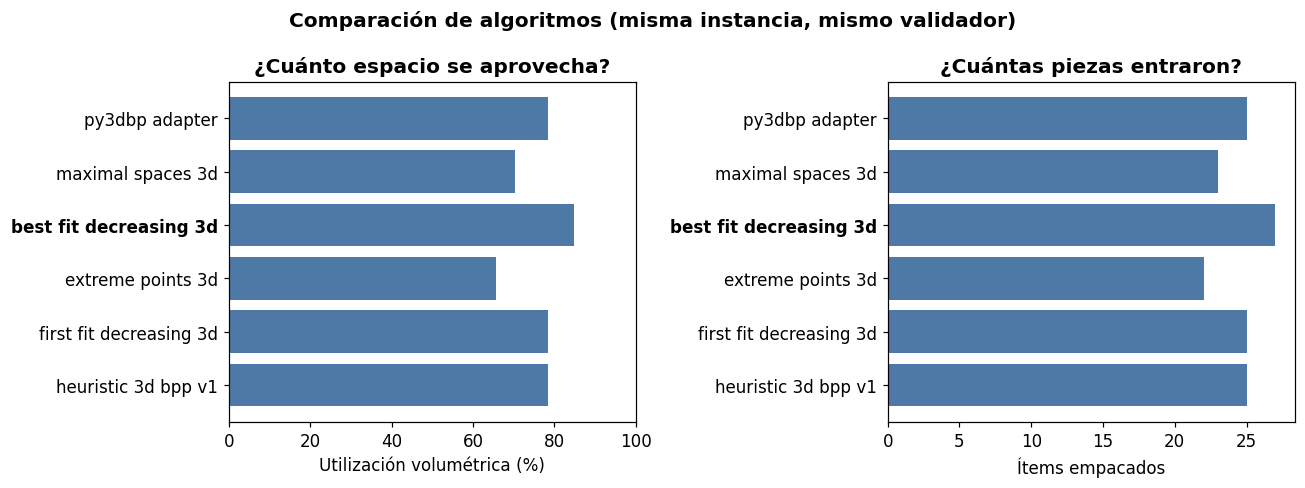

Ganador: best_fit_decreasing_3d


In [3]:
print('═══ BENCHMARK HOMOGÉNEO (3D-BPP) ═══')
response = display.run_and_show_showcase_benchmark('3D_BPP', instance)
print(f'Ganador: {response.ranking[0]}')


═══ 5. LAYOUTS: MEJOR vs PEOR ═══
--- MEJOR: best_fit_decreasing_3d (27 empacados, 84.8%) ---


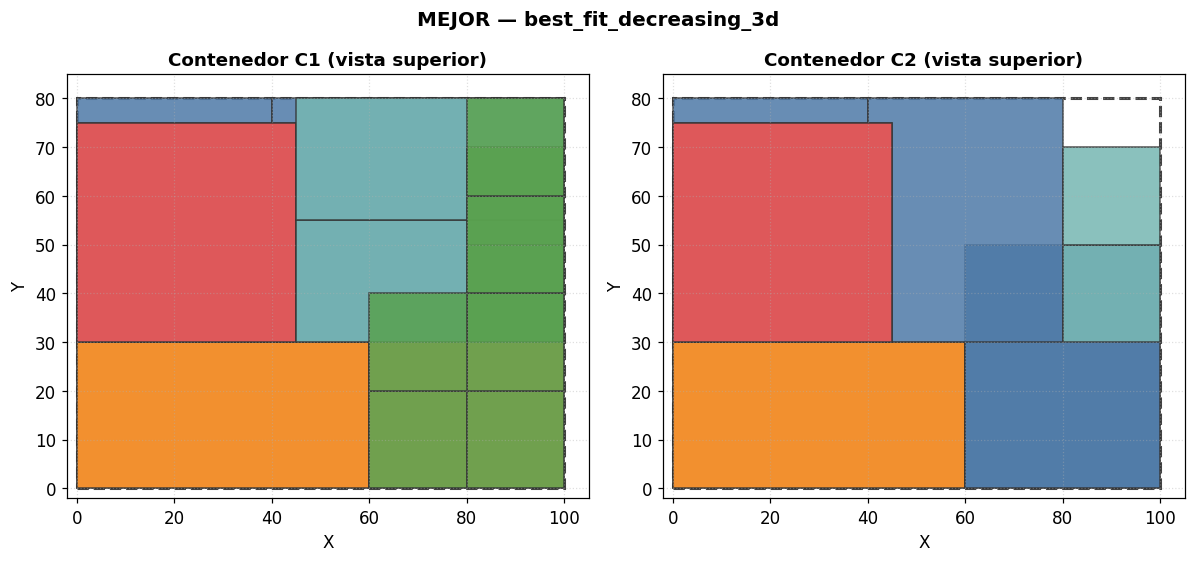

--- PEOR: extreme_points_3d (22 empacados, 65.7%) ---


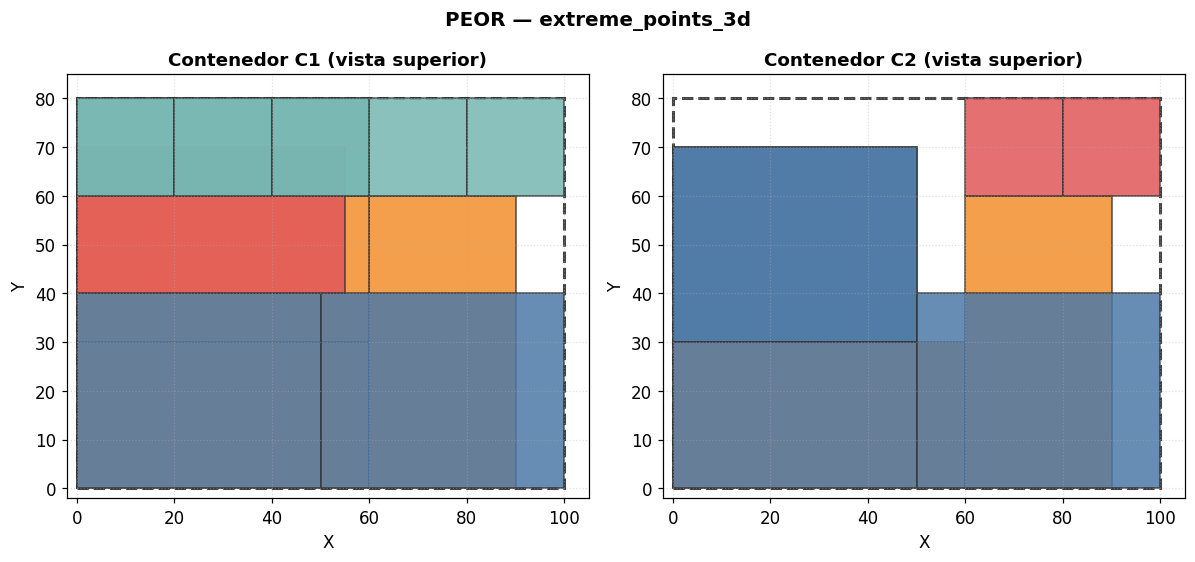

In [4]:
print('═══ 5. LAYOUTS: MEJOR vs PEOR ═══')
from packing_services.domain.models import Container
containers = [Container(**c) for c in instance['containers']]
best = next(r for r in response.results if r.engine == response.ranking[0])
worst = next(r for r in response.results if r.engine == response.ranking[-1])
for label, result in [('MEJOR', best), ('PEOR', worst)]:
    if result.solution:
        print(f'--- {label}: {result.engine} ({result.metrics.items_packed} empacados, {result.metrics.volume_utilization*100:.1f}%) ---')
        fig = viz.plot_all_container_views(result.solution, containers, title_prefix=label)
        if fig: plt.show()


**Mensaje clave:** misma entrada, distintas salidas — el benchmark cuantifica la brecha entre heurísticas.

**Siguiente:** mejora local y otros tipos en `08_catalogo_algoritmos_y_futuro.ipynb`.

Luego: `04_validacion_independiente.ipynb`
